In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
df=pd.read_csv("C:\\Users\\BHIMA SHANKAR\\Downloads\\car_price_prediction.csv")
le = LabelEncoder()
df['Fuel type'] = le.fit_transform(df['Fuel type'])
df['Fuel type']
df = pd.get_dummies(df, columns=['Color'], drop_first=True)
df

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,...,Color_Green,Color_Grey,Color_Orange,Color_Pink,Color_Purple,Color_Red,Color_Silver,Color_Sky blue,Color_White,Color_Yellow
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,2,3.5,...,False,False,False,False,False,False,True,False,False,False
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,5,3,...,False,False,False,False,False,False,False,False,False,False
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,5,1.3,...,False,False,False,False,False,False,False,False,False,False
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,2,2.5,...,False,False,False,False,False,False,False,False,True,False
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,5,1.3,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,45798355,8467,-,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,0,2.0 Turbo,...,False,False,False,False,False,False,True,False,False,False
19233,45778856,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,5,2.4,...,False,False,False,False,False,True,False,False,False,False
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,1,2,...,False,True,False,False,False,False,False,False,False,False
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,1,2,...,False,False,False,False,False,False,False,False,False,False


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   19237 non-null  int64  
 1   Price                19237 non-null  int64  
 2   Levy                 19237 non-null  object 
 3   Manufacturer         19237 non-null  object 
 4   Model                19237 non-null  object 
 5   Prod. year           19237 non-null  int64  
 6   Category             19237 non-null  object 
 7   Leather interior     19237 non-null  object 
 8   Fuel type            19237 non-null  int64  
 9   Engine volume        19237 non-null  object 
 10  Mileage              19237 non-null  object 
 11  Cylinders            19237 non-null  float64
 12  Gear box type        19237 non-null  object 
 13  Drive wheels         19237 non-null  object 
 14  Doors                19237 non-null  object 
 15  Wheel                19237 non-null 

In [3]:
df.isnull().sum()

ID                     0
Price                  0
Levy                   0
Manufacturer           0
Model                  0
Prod. year             0
Category               0
Leather interior       0
Fuel type              0
Engine volume          0
Mileage                0
Cylinders              0
Gear box type          0
Drive wheels           0
Doors                  0
Wheel                  0
Airbags                0
Color_Black            0
Color_Blue             0
Color_Brown            0
Color_Carnelian red    0
Color_Golden           0
Color_Green            0
Color_Grey             0
Color_Orange           0
Color_Pink             0
Color_Purple           0
Color_Red              0
Color_Silver           0
Color_Sky blue         0
Color_White            0
Color_Yellow           0
dtype: int64

In [7]:
df[["Manufacturer", "Model"]].value_counts()

Manufacturer   Model            
TOYOTA         Prius                1083
HYUNDAI        Sonata               1079
TOYOTA         Camry                 938
HYUNDAI        Elantra               922
MERCEDES-BENZ  E 350                 542
                                    ... 
KIA            Sportage SX             1
               Sportage PRESTIGE       1
               Sportage EX             1
               Sorento SX              1
სხვა           IVECO DAYLY             1
Name: count, Length: 1601, dtype: int64

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score


df = pd.read_csv("C:\\Users\\BHIMA SHANKAR\\Downloads\\car_price_prediction.csv")
df.head(19365)



,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,45798355,8467,-,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
19233,45778856,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4.0,Automatic,Front,04-May,Left wheel,Black,4


In [34]:
df['Levy'] = df['Levy'].replace('-', np.nan)
df['Levy'] = pd.to_numeric(df['Levy'], errors='coerce')

df['Mileage'] = df['Mileage'].str.replace(' km', '', regex=False)
df['Mileage'] = pd.to_numeric(df['Mileage'], errors='coerce')

df['Engine volume'] = df['Engine volume'].str.replace(' Turbo', '', regex=False)
df['Engine volume'] = pd.to_numeric(df['Engine volume'], errors='coerce')
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Price'] >= lower) & (df['Price'] <= upper)]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18164 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                18164 non-null  int64  
 1   Price             18164 non-null  int64  
 2   Levy              18164 non-null  float64
 3   Manufacturer      18164 non-null  object 
 4   Model             18164 non-null  object 
 5   Prod. year        18164 non-null  int64  
 6   Category          18164 non-null  object 
 7   Leather interior  18164 non-null  object 
 8   Fuel type         18164 non-null  object 
 9   Engine volume     18164 non-null  float64
 10  Mileage           18164 non-null  int64  
 11  Cylinders         18164 non-null  float64
 12  Gear box type     18164 non-null  object 
 13  Drive wheels      18164 non-null  object 
 14  Doors             18164 non-null  object 
 15  Wheel             18164 non-null  object 
 16  Color             18164 non-null  object 
 17

C:\Users\BHIMA SHANKAR\AppData\Local\Temp\ipykernel_11160\2831149650.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


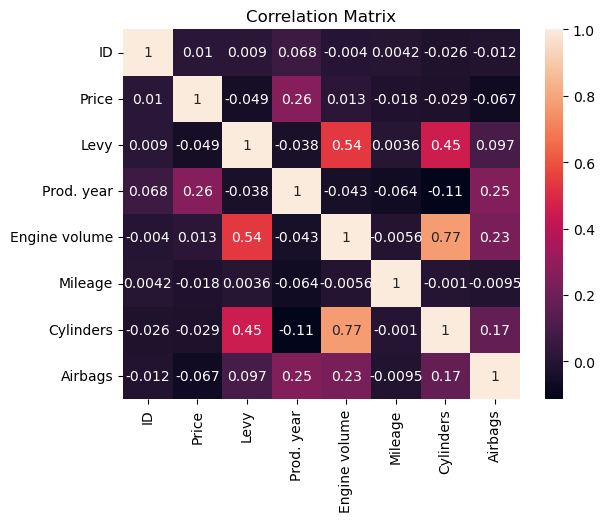

In [23]:
plt.figure()
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [24]:
round(df['Price'].mean(), 2)

np.float64(14024.92)

In [30]:
df['Manufacturer'].value_counts()

Manufacturer
TOYOTA           3558
HYUNDAI          3460
MERCEDES-BENZ    1905
FORD             1056
CHEVROLET        1043
                 ... 
PONTIAC             1
LANCIA              1
FERRARI             1
HAVAL               1
GREATWALL           1
Name: count, Length: 61, dtype: int64

In [41]:
X = df.drop('Price', axis=1)
y = df['Price']

X = pd.get_dummies(X, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
r2_lr = r2_score(y_test, y_pred_lr)

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
r2_lr
r2_rf


0.7836908088575547

In [42]:
{
    "Linear Regression R²": round(r2_lr, 4),
    "Random Forest R²": round(r2_rf, 4)
}


{'Linear Regression R²': 0.3797, 'Random Forest R²': 0.7837}